# Comparing Eigenoptions: Graph Laplacian vs Successor Representation

This notebook compares two ways to construct eigenoptions in the same FourRooms task:

- **Graph Laplacian eigenoptions**, built from proto-value functions of the normalized graph Laplacian.
- **Successor Representation eigenoptions**, built from eigenvectors of the random-policy SR matrix.

The option construction is fixed and task-agnostic. During task learning, both methods use the same DQN-style high-level controller over primitive actions plus fixed eigenoptions. The controller is neural, but option execution remains semi-Markov: when an option is selected it runs until its termination condition, the goal, truncation, or the episode step limit.


# Setup
Imports, seeds, output directory, and device selection.


In [1]:
import math
import random
from collections import deque, Counter
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import gymnasium as gym
from gymnasium import spaces
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
from matplotlib.colors import TwoSlopeNorm

SAVE_FIGURES = False
OUTPUT_DIR = Path("comparison_plots")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


def set_seed(seed=1234):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(1234)


/home/vishnu/miniforge3/envs/rl_test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


# Config
The defaults are CPU-friendly while preserving the comparison logic. Increase `n_runs`, `num_episodes`, or `num_options_to_use` for a heavier experiment.


In [2]:
HYPERPARAMS = {
    # Environment and experiment
    "seed": 1234,
    "n_runs": 2,
    "num_episodes": 700,
    "max_steps": 200,
    "initial_goal": (0, 10),
    "switched_goal": (10, 10),
    "mastery_window": 50,
    "mastery_reward": 1.0,

    # Option construction
    "gamma": 0.90,
    "sr_gamma": 0.90,
    "eigenpurpose_k": 32,
    "num_options_to_use": 64,
    "option_value_tol": 1e-8,
    "option_term_epsilon": 1e-7,

    # DQN controller
    "hidden_dim": 128,
    "dqn_lr": 2e-3,
    "batch_size": 64,
    "replay_size": 50_000,
    "min_replay_size": 500,
    "target_update_freq": 250,
    "train_updates_per_high_level_step": 1,
    "grad_clip_norm": 10.0,

    # Exploration
    "epsilon_start": 1.0,
    "epsilon_min": 0.05,
    "epsilon_decay_episodes": 500,
    "epsilon_boost_after_switch": 0.50,

    # Evaluation and plotting
    "num_eval_episodes": 10,
    "plot_smooth_window": 35,
    "plot_eigenvectors": 6,
    "plot_options": 24,
}

METHODS = {
    "laplacian": "Graph Laplacian EO + DQN",
    "sr": "SR EO + DQN",
}


# Environment
The same 11x11 FourRooms grid is used for both methods. Observations include coordinates and doorway-visit flags, but the DQN controller uses a one-hot state index for stable tabular-style neural learning.


In [3]:
class FourRoomsEnv(gym.Env):
    """11x11 FourRooms gridworld with four doorway bottlenecks."""

    metadata = {"render_modes": []}

    def __init__(self, bottleneck_rewards=False, goal_state=(0, 10)):
        super().__init__()
        self.grid_size = 11
        self.max_steps = 200
        self.bottleneck_rewards = bottleneck_rewards
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(
            low=0.0,
            high=float(self.grid_size),
            shape=(6,),
            dtype=np.float32,
        )
        self.goal_state = tuple(goal_state)

        self.walls = set()
        for i in range(self.grid_size):
            self.walls.add((5, i))
            self.walls.add((i, 5))
        self.doorway_list = [(5, 1), (5, 8), (2, 5), (9, 5)]
        for doorway in self.doorway_list:
            self.walls.remove(doorway)

        self.valid_states = [
            (r, c)
            for r in range(self.grid_size)
            for c in range(self.grid_size)
            if (r, c) not in self.walls
        ]
        self.state_to_idx = {state: idx for idx, state in enumerate(self.valid_states)}
        self.idx_to_state = {idx: state for state, idx in self.state_to_idx.items()}
        self.num_states = len(self.valid_states)

        self.current_state = None
        self.current_step = 0
        self.visited_doorways = set()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.visited_doorways.clear()
        idx = self.np_random.integers(0, len(self.valid_states))
        while self.valid_states[idx] == self.goal_state:
            idx = self.np_random.integers(0, len(self.valid_states))
        self.current_state = self.valid_states[idx]
        return self._get_obs(), {}

    def step(self, action):
        action = int(action)
        self.current_step += 1
        r, c = self.current_state
        if action == 0:
            r -= 1
        elif action == 1:
            c += 1
        elif action == 2:
            r += 1
        elif action == 3:
            c -= 1

        if 0 <= r < self.grid_size and 0 <= c < self.grid_size and (r, c) not in self.walls:
            self.current_state = (r, c)

        terminated = self.current_state == self.goal_state
        truncated = self.current_step >= self.max_steps
        reward = 1.0 if terminated else 0.0

        if (
            self.bottleneck_rewards
            and self.current_state in self.doorway_list
            and self.current_state not in self.visited_doorways
        ):
            reward += 0.5
            self.visited_doorways.add(self.current_state)

        return self._get_obs(), reward, terminated, truncated, {}

    def _get_obs(self):
        r, c = self.current_state
        obs = [float(r), float(c)]
        obs.extend(1.0 if doorway in self.visited_doorways else 0.0 for doorway in self.doorway_list)
        return np.array(obs, dtype=np.float32)

    def get_state_idx(self):
        return self.state_to_idx[self.current_state]

    def set_state(self, state):
        self.current_state = tuple(state)
        self.current_step = 0
        self.visited_doorways.clear()
        return self._get_obs()


def build_transition_table(env):
    """Deterministic next-state table for primitive actions."""
    table = np.zeros((env.num_states, 4), dtype=np.int64)
    for s_idx, (r, c) in env.idx_to_state.items():
        candidates = [(r - 1, c), (r, c + 1), (r + 1, c), (r, c - 1)]
        for action, next_state in enumerate(candidates):
            if (
                0 <= next_state[0] < env.grid_size
                and 0 <= next_state[1] < env.grid_size
                and next_state not in env.walls
            ):
                table[s_idx, action] = env.state_to_idx[next_state]
            else:
                table[s_idx, action] = s_idx
    return table


env_probe = FourRoomsEnv(goal_state=HYPERPARAMS["initial_goal"])
TRANSITIONS = build_transition_table(env_probe)
print(f"FourRooms valid states: {env_probe.num_states}")


FourRooms valid states: 104


# Option Construction
Both pipelines produce fixed eigenoptions with the same interface. The eigenpurpose vector supplies intrinsic reward `e(next_state) - e(state)`, and value iteration solves the optimal terminating option policy.


In [4]:
@dataclass
class EigenoptionPolicy:
    pi: np.ndarray
    option_id: int
    eigenvalue: float
    eigenpurpose: np.ndarray
    method: str
    source_index: int
    direction: str

    def act(self, s_idx, env=None):
        return int(self.pi[s_idx])

    def is_terminal(self, s_idx, env=None):
        return int(self.pi[s_idx]) == 4

    def can_initiate(self, s_idx, env=None):
        return int(self.pi[s_idx]) != 4

    @property
    def initiation_states(self):
        return np.where(self.pi != 4)[0]

    @property
    def termination_states(self):
        return np.where(self.pi == 4)[0]


def normalize_vectors(eigenvectors):
    vectors = np.asarray(eigenvectors, dtype=np.float64).copy()
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    norms[norms == 0.0] = 1.0
    return vectors / norms


def solve_eigenoption_policy(env, eigenpurpose, gamma, value_tol=1e-8, term_epsilon=1e-7, max_iters=10_000):
    """Value iteration for a deterministic option with an explicit terminate action."""
    next_states = build_transition_table(env)
    n = env.num_states
    eigenpurpose = np.asarray(eigenpurpose, dtype=np.float64)
    rewards = eigenpurpose[next_states] - eigenpurpose[:, None]
    values = np.zeros(n, dtype=np.float64)

    for _ in range(max_iters):
        q_primitive = rewards + gamma * values[next_states]
        best_primitive = np.max(q_primitive, axis=1)
        new_values = np.maximum(0.0, best_primitive)
        delta = np.max(np.abs(new_values - values))
        values = new_values
        if delta < value_tol:
            break

    q_primitive = rewards + gamma * values[next_states]
    best_actions = np.argmax(q_primitive, axis=1).astype(np.int64)
    best_values = np.max(q_primitive, axis=1)
    policy = np.where(best_values > term_epsilon, best_actions, 4).astype(np.int64)
    return policy, values


def build_adjacency_matrix(env):
    adjacency = np.zeros((env.num_states, env.num_states), dtype=np.float64)
    next_states = build_transition_table(env)
    for s_idx in range(env.num_states):
        for next_idx in next_states[s_idx]:
            if next_idx != s_idx:
                adjacency[s_idx, next_idx] = 1.0
                adjacency[next_idx, s_idx] = 1.0
    return adjacency


def laplacian_eigenpairs(env):
    adjacency = build_adjacency_matrix(env)
    degree = adjacency.sum(axis=1)
    inv_sqrt_degree = 1.0 / np.sqrt(degree + 1e-12)
    laplacian = np.eye(env.num_states) - (inv_sqrt_degree[:, None] * adjacency * inv_sqrt_degree[None, :])
    eigenvalues, eigenvectors_col = np.linalg.eigh(laplacian)
    order = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors_col[:, order].T
    return eigenvalues[1:], normalize_vectors(eigenvectors[1:]), laplacian


def build_random_policy_transition_matrix(env):
    transitions = build_transition_table(env)
    p_mat = np.zeros((env.num_states, env.num_states), dtype=np.float64)
    for s_idx in range(env.num_states):
        for next_idx in transitions[s_idx]:
            p_mat[s_idx, next_idx] += 0.25
    return p_mat


def sr_eigenpairs(env, gamma):
    p_mat = build_random_policy_transition_matrix(env)
    sr_matrix = np.linalg.inv(np.eye(env.num_states) - gamma * p_mat)
    eigenvalues, eigenvectors_col = np.linalg.eig(sr_matrix)
    eigenvalues = np.real_if_close(eigenvalues, tol=1000).real
    eigenvectors = np.real_if_close(eigenvectors_col, tol=1000).real.T
    order = np.argsort(-eigenvalues)
    return eigenvalues[order], normalize_vectors(eigenvectors[order]), sr_matrix


def build_option_bank(env, eigenvalues, eigenvectors, method, gamma, eigenpurpose_k, start_index=0):
    options = []
    stop = min(start_index + eigenpurpose_k, len(eigenvectors))
    iterator = tqdm(range(start_index, stop), desc=f"Building {method} options", leave=False, dynamic_ncols=True, mininterval=0.5)
    for eig_idx in iterator:
        base_vector = eigenvectors[eig_idx]
        for sign, direction in [(1.0, "positive"), (-1.0, "negative")]:
            eigenpurpose = sign * base_vector
            policy, _ = solve_eigenoption_policy(
                env,
                eigenpurpose,
                gamma=gamma,
                value_tol=HYPERPARAMS["option_value_tol"],
                term_epsilon=HYPERPARAMS["option_term_epsilon"],
            )
            options.append(
                EigenoptionPolicy(
                    pi=policy,
                    option_id=len(options),
                    eigenvalue=float(eigenvalues[eig_idx]),
                    eigenpurpose=eigenpurpose,
                    method=method,
                    source_index=int(eig_idx),
                    direction=direction,
                )
            )
    return options


def select_options(options, num_options, method):
    if method == "laplacian":
        ordered = sorted(options, key=lambda opt: (opt.eigenvalue, opt.source_index, opt.direction))
    else:
        ordered = sorted(options, key=lambda opt: (-opt.eigenvalue, opt.source_index, opt.direction))
    selected = ordered[:num_options]
    for new_id, opt in enumerate(selected):
        opt.option_id = new_id
    return selected


def build_all_option_sets(hyperparams):
    env = FourRoomsEnv(goal_state=hyperparams["initial_goal"])

    lap_values, lap_vectors, lap_matrix = laplacian_eigenpairs(env)
    lap_bank = build_option_bank(
        env,
        lap_values,
        lap_vectors,
        method="laplacian",
        gamma=hyperparams["gamma"],
        eigenpurpose_k=hyperparams["eigenpurpose_k"],
        start_index=0,
    )
    lap_options = select_options(lap_bank, hyperparams["num_options_to_use"], "laplacian")

    sr_values, sr_vectors, sr_matrix = sr_eigenpairs(env, hyperparams["sr_gamma"])
    sr_bank = build_option_bank(
        env,
        sr_values,
        sr_vectors,
        method="sr",
        gamma=hyperparams["gamma"],
        eigenpurpose_k=hyperparams["eigenpurpose_k"],
        start_index=1,  # skip the nearly constant SR eigenvector
    )
    sr_options = select_options(sr_bank, hyperparams["num_options_to_use"], "sr")

    spectral_data = {
        "laplacian_eigenvalues": lap_values,
        "laplacian_eigenvectors": lap_vectors,
        "laplacian_matrix": lap_matrix,
        "sr_eigenvalues": sr_values,
        "sr_eigenvectors": sr_vectors,
        "sr_matrix": sr_matrix,
    }
    return {"laplacian": lap_options, "sr": sr_options}, spectral_data


option_sets, spectral_data = build_all_option_sets(HYPERPARAMS)
for key, opts in option_sets.items():
    print(f"{METHODS[key]}: {len(opts)} options")


Graph Laplacian EO + DQN: 64 options
SR EO + DQN: 64 options


# DQN High-Level Controller
The DQN chooses high-level actions: primitive moves `0..3` plus eigenoptions `4..`. Invalid eigenoptions are masked during exploration, greedy selection, and target computation.


In [5]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.storage = deque(maxlen=int(capacity))

    def push(self, state, action, reward, next_state, done, discount):
        self.storage.append((int(state), int(action), float(reward), int(next_state), float(done), float(discount)))

    def sample(self, batch_size):
        batch = random.sample(self.storage, int(batch_size))
        states, actions, rewards, next_states, dones, discounts = zip(*batch)
        return (
            torch.as_tensor(states, dtype=torch.long, device=DEVICE),
            torch.as_tensor(actions, dtype=torch.long, device=DEVICE),
            torch.as_tensor(rewards, dtype=torch.float32, device=DEVICE),
            torch.as_tensor(next_states, dtype=torch.long, device=DEVICE),
            torch.as_tensor(dones, dtype=torch.float32, device=DEVICE),
            torch.as_tensor(discounts, dtype=torch.float32, device=DEVICE),
        )

    def __len__(self):
        return len(self.storage)


class DQNNetwork(nn.Module):
    def __init__(self, num_states, num_actions, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_states, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_actions),
        )

    def forward(self, state_idx):
        one_hot = F.one_hot(state_idx.long(), num_classes=self.net[0].in_features).float()
        return self.net(one_hot)


class DQNOptionAgent:
    def __init__(self, env, options, hyperparams, seed_offset=0):
        self.env = env
        self.options = options
        self.num_states = env.num_states
        self.num_primitive = 4
        self.num_actions = self.num_primitive + len(options)
        self.gamma = hyperparams["gamma"]
        self.batch_size = hyperparams["batch_size"]
        self.min_replay_size = hyperparams["min_replay_size"]
        self.target_update_freq = hyperparams["target_update_freq"]
        self.grad_clip_norm = hyperparams["grad_clip_norm"]
        self.epsilon = hyperparams["epsilon_start"]
        self.epsilon_min = hyperparams["epsilon_min"]
        self.epsilon_decay = (hyperparams["epsilon_start"] - hyperparams["epsilon_min"]) / max(1, hyperparams["epsilon_decay_episodes"])

        torch.manual_seed(hyperparams["seed"] + seed_offset)
        self.online = DQNNetwork(self.num_states, self.num_actions, hyperparams["hidden_dim"]).to(DEVICE)
        self.target = DQNNetwork(self.num_states, self.num_actions, hyperparams["hidden_dim"]).to(DEVICE)
        self.target.load_state_dict(self.online.state_dict())
        self.optimizer = optim.Adam(self.online.parameters(), lr=hyperparams["dqn_lr"])
        self.replay = ReplayBuffer(hyperparams["replay_size"])
        self.update_steps = 0
        self.last_loss = np.nan

    def valid_actions(self, state_idx):
        valid = list(range(self.num_primitive))
        for opt_idx, option in enumerate(self.options):
            if option.can_initiate(state_idx, self.env):
                valid.append(self.num_primitive + opt_idx)
        return valid

    def valid_action_mask(self, state_indices):
        state_indices = np.asarray(state_indices, dtype=np.int64)
        mask = np.zeros((len(state_indices), self.num_actions), dtype=bool)
        mask[:, :self.num_primitive] = True
        for row, state_idx in enumerate(state_indices):
            for opt_idx, option in enumerate(self.options):
                if option.can_initiate(int(state_idx), self.env):
                    mask[row, self.num_primitive + opt_idx] = True
        return torch.as_tensor(mask, dtype=torch.bool, device=DEVICE)

    def select_action(self, state_idx, greedy=False):
        valid = self.valid_actions(state_idx)
        if (not greedy) and np.random.rand() < self.epsilon:
            return int(np.random.choice(valid))

        with torch.no_grad():
            state_tensor = torch.as_tensor([state_idx], dtype=torch.long, device=DEVICE)
            q_values = self.online(state_tensor)[0]
            invalid = torch.ones(self.num_actions, dtype=torch.bool, device=DEVICE)
            invalid[valid] = False
            q_values = q_values.masked_fill(invalid, -1e9)
            return int(torch.argmax(q_values).item())

    def remember(self, state, action, reward, next_state, done, duration):
        discount = self.gamma ** max(1, int(duration))
        self.replay.push(state, action, reward, next_state, done, discount)

    def train_step(self):
        if len(self.replay) < self.min_replay_size or len(self.replay) < self.batch_size:
            return np.nan

        states, actions, rewards, next_states, dones, discounts = self.replay.sample(self.batch_size)
        q_values = self.online(states).gather(1, actions[:, None]).squeeze(1)

        with torch.no_grad():
            next_q = self.target(next_states)
            valid_mask = self.valid_action_mask(next_states.detach().cpu().numpy())
            next_q = next_q.masked_fill(~valid_mask, -1e9)
            next_values = next_q.max(dim=1).values
            targets = rewards + (1.0 - dones) * discounts * next_values

        loss = F.smooth_l1_loss(q_values, targets)
        self.optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(self.online.parameters(), self.grad_clip_norm)
        self.optimizer.step()

        self.update_steps += 1
        if self.update_steps % self.target_update_freq == 0:
            self.target.load_state_dict(self.online.state_dict())

        self.last_loss = float(loss.item())
        return self.last_loss

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon - self.epsilon_decay)

    def boost_epsilon(self, value):
        self.epsilon = max(self.epsilon, float(value))

    def state_values(self):
        values = np.zeros(self.num_states, dtype=np.float64)
        with torch.no_grad():
            states = torch.arange(self.num_states, dtype=torch.long, device=DEVICE)
            q_values = self.online(states)
            valid_mask = self.valid_action_mask(np.arange(self.num_states))
            q_values = q_values.masked_fill(~valid_mask, -1e9)
            values = q_values.max(dim=1).values.detach().cpu().numpy()
        return values


# Training
Both agents are trained in lockstep. The goal switches only after **both** agents have a rolling 50-episode average return equal to `+1.0`.


In [6]:
def execute_high_level_action(env, options, state_idx, action_idx, max_remaining_steps, gamma, record=False):
    """Execute one primitive action or one fixed eigenoption."""
    num_primitive = 4
    transitions = []
    discounted_reward = 0.0
    total_reward = 0.0
    duration = 0
    terminated = False
    truncated = False
    option_id = None

    if action_idx < num_primitive:
        start_state = env.idx_to_state[state_idx]
        _, reward, terminated, truncated, _ = env.step(action_idx)
        next_state_idx = env.get_state_idx()
        end_state = env.idx_to_state[next_state_idx]
        transitions.append((start_state, end_state))
        discounted_reward = float(reward)
        total_reward = float(reward)
        duration = 1
        return {
            "next_state_idx": next_state_idx,
            "discounted_reward": discounted_reward,
            "total_reward": total_reward,
            "duration": duration,
            "done": bool(terminated or truncated),
            "terminated": bool(terminated),
            "truncated": bool(truncated),
            "transitions": transitions if record else None,
            "option_id": option_id,
        }

    option_id = int(action_idx - num_primitive)
    option = options[option_id]

    while duration < max_remaining_steps:
        if option.is_terminal(state_idx, env):
            break
        primitive_action = option.act(state_idx, env)
        start_state = env.idx_to_state[state_idx]
        _, reward, terminated, truncated, _ = env.step(primitive_action)
        next_state_idx = env.get_state_idx()
        end_state = env.idx_to_state[next_state_idx]

        transitions.append((start_state, end_state))
        discounted_reward += (gamma ** duration) * float(reward)
        total_reward += float(reward)
        duration += 1
        state_idx = next_state_idx

        if terminated or truncated:
            break

    if duration == 0:
        # This should be unreachable because invalid options are masked. Keep a safe no-op transition.
        duration = 1

    return {
        "next_state_idx": state_idx,
        "discounted_reward": discounted_reward,
        "total_reward": total_reward,
        "duration": duration,
        "done": bool(terminated or truncated),
        "terminated": bool(terminated),
        "truncated": bool(truncated),
        "transitions": transitions if record else None,
        "option_id": option_id,
    }


def run_dqn_episode(env, agent, options, hyperparams, train=True, greedy=False, start_state=None, record=False):
    if start_state is None:
        env.reset()
    else:
        env.reset()
        env.current_state = tuple(start_state)
        env.current_step = 0
        env.visited_doorways.clear()

    state_idx = env.get_state_idx()
    total_reward = 0.0
    primitive_steps = 0
    high_level_steps = 0
    success = 0.0
    losses = []
    trajectory = []
    option_usage = Counter()
    option_durations = []

    while primitive_steps < hyperparams["max_steps"]:
        action_idx = agent.select_action(state_idx, greedy=greedy)
        max_remaining = hyperparams["max_steps"] - primitive_steps
        result = execute_high_level_action(
            env,
            options,
            state_idx,
            action_idx,
            max_remaining_steps=max_remaining,
            gamma=hyperparams["gamma"],
            record=record,
        )

        if record and result["transitions"]:
            trajectory.append({
                "high_level_action": action_idx,
                "transitions": result["transitions"],
                "duration": result["duration"],
                "option_id": result["option_id"],
            })

        if result["option_id"] is not None:
            option_usage[result["option_id"]] += 1
            option_durations.append(result["duration"])

        if train:
            agent.remember(
                state_idx,
                action_idx,
                result["discounted_reward"],
                result["next_state_idx"],
                result["done"],
                result["duration"],
            )
            for _ in range(hyperparams["train_updates_per_high_level_step"]):
                loss = agent.train_step()
                if np.isfinite(loss):
                    losses.append(loss)

        state_idx = result["next_state_idx"]
        total_reward += result["total_reward"]
        primitive_steps += result["duration"]
        high_level_steps += 1

        if result["terminated"]:
            success = 1.0
        if result["done"]:
            break

    if train:
        agent.decay_epsilon()

    return {
        "reward": total_reward,
        "steps": primitive_steps,
        "high_level_steps": high_level_steps,
        "success": success,
        "loss": float(np.mean(losses)) if losses else np.nan,
        "trajectory": trajectory,
        "option_usage": option_usage,
        "option_durations": option_durations,
    }


def rolling_mean(values, window):
    if len(values) < window:
        return np.nan
    return float(np.mean(values[-window:]))


def run_comparison_experiment(option_sets, hyperparams):
    results = {
        key: {
            "rewards": [],
            "steps": [],
            "success": [],
            "losses": [],
            "epsilons": [],
            "final_agent": None,
        }
        for key in METHODS
    }
    results["switch_episodes"] = []
    results["option_sets"] = option_sets

    for run in range(hyperparams["n_runs"]):
        set_seed(hyperparams["seed"] + 1000 * run)
        envs = {
            key: FourRoomsEnv(goal_state=hyperparams["initial_goal"])
            for key in METHODS
        }
        agents = {
            key: DQNOptionAgent(envs[key], option_sets[key], hyperparams, seed_offset=run * 13 + idx)
            for idx, key in enumerate(METHODS)
        }

        run_logs = {
            key: {"rewards": [], "steps": [], "success": [], "losses": [], "epsilons": []}
            for key in METHODS
        }
        switched = False
        switch_episode = None

        pbar = tqdm(
            range(hyperparams["num_episodes"]),
            desc=f"DQN comparison run {run + 1}/{hyperparams['n_runs']}",
            leave=True,
            dynamic_ncols=True,
            mininterval=0.5,
            maxinterval=2.0,
            smoothing=0.1,
        )
        for episode in pbar:
            metric_sources = {"rewards": "reward", "steps": "steps", "success": "success", "losses": "loss"}
            for key in METHODS:
                episode_out = run_dqn_episode(envs[key], agents[key], option_sets[key], hyperparams, train=True)
                for metric, source_name in metric_sources.items():
                    run_logs[key][metric].append(episode_out[source_name])
                run_logs[key]["epsilons"].append(agents[key].epsilon)

            lap_avg = rolling_mean(run_logs["laplacian"]["rewards"], hyperparams["mastery_window"])
            sr_avg = rolling_mean(run_logs["sr"]["rewards"], hyperparams["mastery_window"])

            if (
                not switched
                and np.isfinite(lap_avg)
                and np.isfinite(sr_avg)
                and np.isclose(lap_avg, hyperparams["mastery_reward"])
                and np.isclose(sr_avg, hyperparams["mastery_reward"])
            ):
                switched = True
                switch_episode = episode
                for key in METHODS:
                    envs[key].goal_state = hyperparams["switched_goal"]
                    agents[key].boost_epsilon(hyperparams["epsilon_boost_after_switch"])

            postfix = {
                "lap50": f"{lap_avg:.2f}" if np.isfinite(lap_avg) else "--",
                "sr50": f"{sr_avg:.2f}" if np.isfinite(sr_avg) else "--",
                "epsL": f"{agents['laplacian'].epsilon:.2f}",
                "epsSR": f"{agents['sr'].epsilon:.2f}",
                "switch": switch_episode if switch_episode is not None else "no",
                "goal": envs["laplacian"].goal_state,
            }
            if np.isfinite(agents["laplacian"].last_loss):
                postfix["lossL"] = f"{agents['laplacian'].last_loss:.3f}"
            if np.isfinite(agents["sr"].last_loss):
                postfix["lossSR"] = f"{agents['sr'].last_loss:.3f}"
            if episode % 5 == 0 or episode == hyperparams["num_episodes"] - 1 or switch_episode == episode:
                pbar.set_postfix(postfix, refresh=False)

        results["switch_episodes"].append(switch_episode)
        for key in METHODS:
            for metric in ["rewards", "steps", "success", "losses", "epsilons"]:
                results[key][metric].append(run_logs[key][metric])
            if run == hyperparams["n_runs"] - 1:
                results[key]["final_agent"] = agents[key]

    return results


experiment_results = run_comparison_experiment(option_sets, HYPERPARAMS)
print("Switch episodes:", experiment_results["switch_episodes"])


DQN comparison run 2/2: 100%|██████████| 700/700 [01:53<00:00,  6.19it/s, lap50=0.90, sr50=0.98, epsL=0.05, epsSR=0.05, switch=386, goal=(10, 10), lossL=0.007, lossSR=0.001]

Switch episodes: [369, 386]


# Evaluation
Greedy evaluation uses fixed start states for both methods, after training. If a training run switched goals, evaluation uses the switched goal; otherwise it uses the initial goal.


In [7]:
def make_eval_start_states(env, num_eval_episodes, seed=2024):
    rng = np.random.default_rng(seed)
    starts = []
    while len(starts) < num_eval_episodes:
        state = env.valid_states[int(rng.integers(0, env.num_states))]
        if state != env.goal_state and state not in starts:
            starts.append(state)
    return starts


def evaluate_agents(results, hyperparams):
    any_switched = any(ep is not None for ep in results["switch_episodes"])
    eval_goal = hyperparams["switched_goal"] if any_switched else hyperparams["initial_goal"]
    eval_env_template = FourRoomsEnv(goal_state=eval_goal)
    start_states = make_eval_start_states(eval_env_template, hyperparams["num_eval_episodes"], seed=hyperparams["seed"] + 777)

    evaluation = {"goal": eval_goal, "start_states": start_states}
    for key in METHODS:
        env = FourRoomsEnv(goal_state=eval_goal)
        agent = results[key]["final_agent"]
        method_eval = {
            "trajectories": {},
            "rewards": [],
            "steps": [],
            "success": [],
            "option_usage": Counter(),
            "option_durations": [],
        }
        for idx, start_state in enumerate(start_states):
            out = run_dqn_episode(
                env,
                agent,
                results["option_sets"][key],
                hyperparams,
                train=False,
                greedy=True,
                start_state=start_state,
                record=True,
            )
            method_eval["trajectories"][idx] = out["trajectory"]
            method_eval["rewards"].append(out["reward"])
            method_eval["steps"].append(out["steps"])
            method_eval["success"].append(out["success"])
            method_eval["option_usage"].update(out["option_usage"])
            method_eval["option_durations"].extend(out["option_durations"])
        evaluation[key] = method_eval
    return evaluation


evaluation_results = evaluate_agents(experiment_results, HYPERPARAMS)
for key in METHODS:
    print(
        f"{METHODS[key]} | eval success={np.mean(evaluation_results[key]['success']):.2f}, "
        f"avg steps={np.mean(evaluation_results[key]['steps']):.1f}, "
        f"goal={evaluation_results['goal']}"
    )


Graph Laplacian EO + DQN | eval success=1.00, avg steps=9.1, goal=(10, 10)
SR EO + DQN | eval success=0.70, avg steps=65.9, goal=(10, 10)


# Visualization Helpers
Reusable plotting utilities for the comparison and explainability panels.


In [8]:
COLORS = {
    "laplacian": "#2266AA",
    "sr": "#CC6677",
    "laplacian_fill": "#9ecae1",
    "sr_fill": "#f2a7b5",
    "wall": "#1f2933",
    "floor": "#f8fafc",
    "grid": "#cbd5e1",
    "text": "#172033",
    "muted": "#667085",
    "goal": "#16a34a",
    "start": "#f59e0b",
    "doorway": "#7c3aed",
    "primitive": "#52525b",
    "switch": "#f97316",
}
OPTION_CMAP = list(plt.get_cmap("tab20").colors)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def maybe_save(fig, name):
    if SAVE_FIGURES:
        OUTPUT_DIR.mkdir(exist_ok=True)
        fig.savefig(OUTPUT_DIR / name, dpi=180, bbox_inches="tight")


def set_panel_title(ax, title, subtitle=None):
    ax.set_title(title, loc="left", fontweight="bold", color=COLORS["text"], pad=8)
    if subtitle:
        ax.text(0.0, 1.01, subtitle, transform=ax.transAxes, ha="left", va="bottom", fontsize=8, color=COLORS["muted"])


def draw_env_grid(ax, env, draw_doorways=True, goal=None):
    ax.set_facecolor(COLORS["floor"])
    ax.set_xlim(-0.5, env.grid_size - 0.5)
    ax.set_ylim(env.grid_size - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.set_xticks(np.arange(-0.5, env.grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env.grid_size, 1), minor=True)
    ax.grid(which="minor", color=COLORS["grid"], linewidth=0.45, alpha=0.7)
    ax.set_xticks([])
    ax.set_yticks([])

    for r, c in env.walls:
        ax.add_patch(mpatches.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor=COLORS["wall"], edgecolor="none", zorder=3))

    if draw_doorways:
        for r, c in env.doorway_list:
            ax.scatter(c, r, marker="s", s=28, color=COLORS["doorway"], alpha=0.75, zorder=5)

    if goal is None:
        goal = env.goal_state
    gr, gc = goal
    ax.scatter(gc, gr, marker="*", s=130, color=COLORS["goal"], edgecolor="white", linewidth=0.7, zorder=6)


def values_to_grid(env, values):
    grid = np.full((env.grid_size, env.grid_size), np.nan, dtype=np.float64)
    for s_idx, (r, c) in env.idx_to_state.items():
        grid[r, c] = values[s_idx]
    return grid


def plot_state_heatmap(ax, env, values, title, subtitle=None, cmap="viridis", vmin=None, vmax=None, center_zero=False, goal=None):
    grid = values_to_grid(env, values)
    norm = None
    if center_zero:
        max_abs = np.nanmax(np.abs(grid)) if np.isfinite(grid).any() else 1.0
        if max_abs == 0:
            max_abs = 1.0
        norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)
    im = ax.imshow(grid, origin="upper", cmap=cmap, vmin=vmin, vmax=vmax, norm=norm)
    draw_env_grid(ax, env, goal=goal)
    set_panel_title(ax, title, subtitle)
    return im


def draw_option_policy(ax, env, option, color, density=1.0):
    deltas = {
        0: (0.0, -0.30),
        1: (0.30, 0.0),
        2: (0.0, 0.30),
        3: (-0.30, 0.0),
    }
    xs, ys, us, vs = [], [], [], []
    tx, ty = [], []
    for s_idx, (r, c) in env.idx_to_state.items():
        action = int(option.pi[s_idx])
        if action == 4:
            tx.append(c)
            ty.append(r)
        else:
            dx, dy = deltas[action]
            xs.append(c)
            ys.append(r)
            us.append(dx)
            vs.append(dy)
    if xs:
        ax.quiver(xs, ys, us, vs, angles="xy", scale_units="xy", scale=1, color=color, width=0.006, headwidth=3.5, headlength=4.4, alpha=0.88, zorder=7)
    if tx:
        ax.scatter(tx, ty, marker="x", s=16 * density, color=COLORS["switch"], linewidths=0.9, zorder=8)


def smooth_1d(values, window):
    arr = np.asarray(values, dtype=np.float64)
    if np.isnan(arr).all():
        arr = np.zeros_like(arr)
    elif np.isnan(arr).any():
        valid = np.where(np.isfinite(arr))[0]
        arr = np.interp(np.arange(len(arr)), valid, arr[valid])
    if len(arr) < window:
        return np.arange(len(arr)), arr
    kernel = np.ones(window) / window
    smoothed = np.convolve(arr, kernel, mode="valid")
    x = np.arange(window - 1, len(arr))
    return x, smoothed


def run_band(runs, window):
    smoothed = []
    for run in runs:
        _, y = smooth_1d(run, window)
        smoothed.append(y)
    min_len = min(len(y) for y in smoothed)
    smoothed = np.array([y[-min_len:] for y in smoothed])
    x = np.arange(len(runs[0]) - min_len, len(runs[0]))
    return x, np.nanmedian(smoothed, axis=0), np.nanpercentile(smoothed, 25, axis=0), np.nanpercentile(smoothed, 75, axis=0)


def high_level_action_color(action):
    if action < 4:
        return COLORS["primitive"]
    return OPTION_CMAP[(action - 4) % len(OPTION_CMAP)]


# Training and Value Plots
Learning curves, spectra, eigenpurpose maps, option policies, and final DQN values.


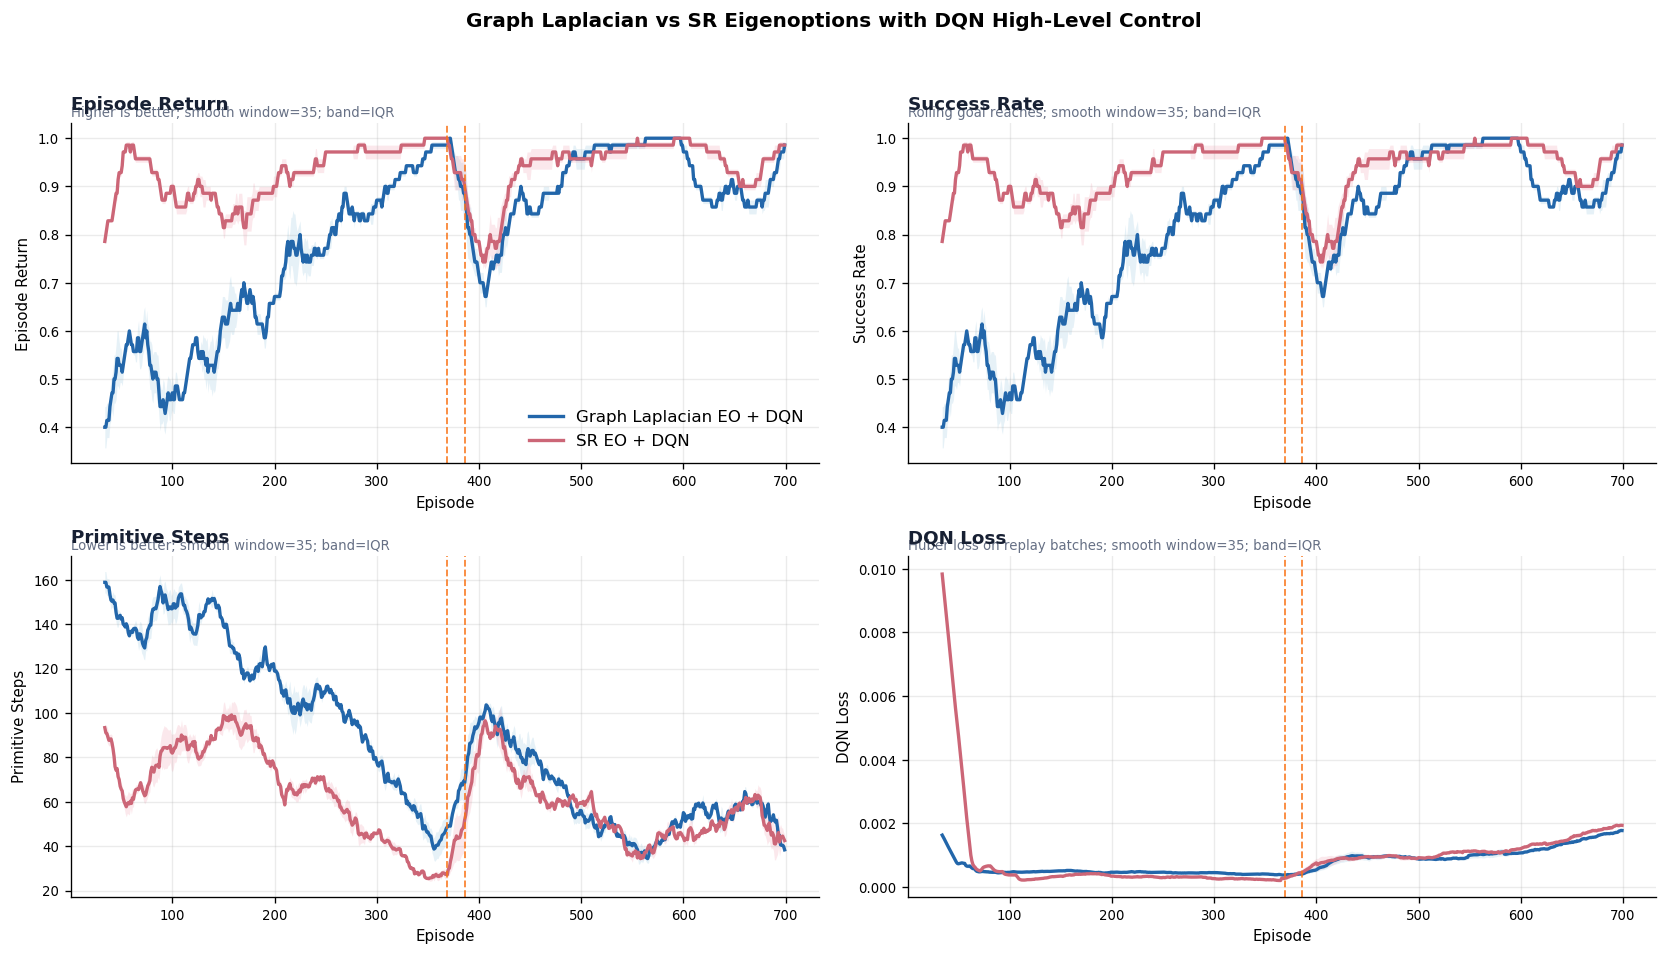

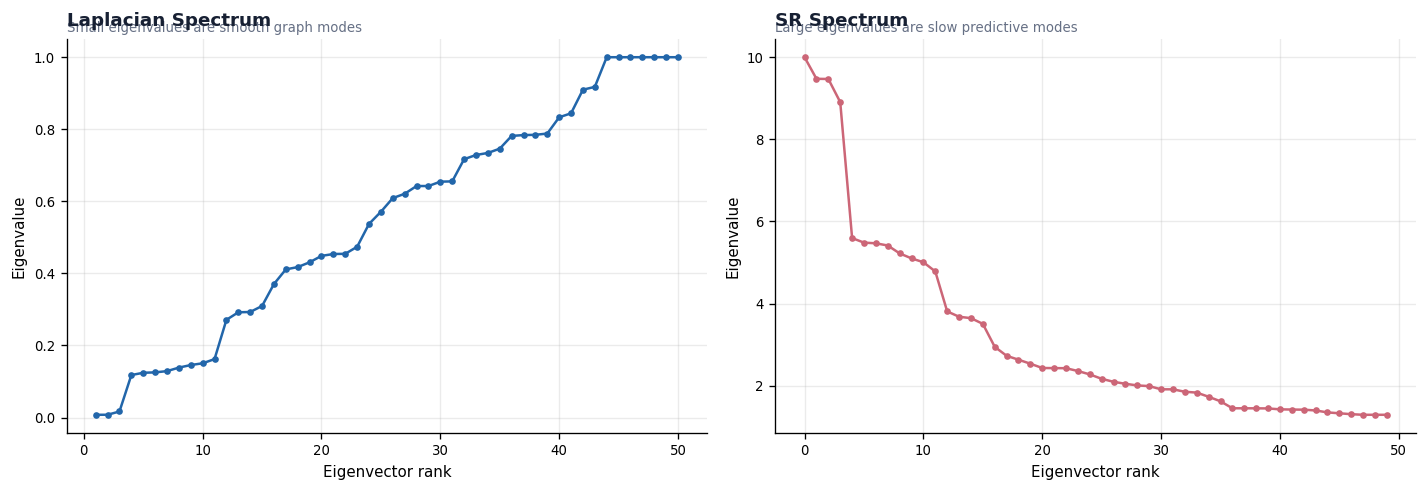

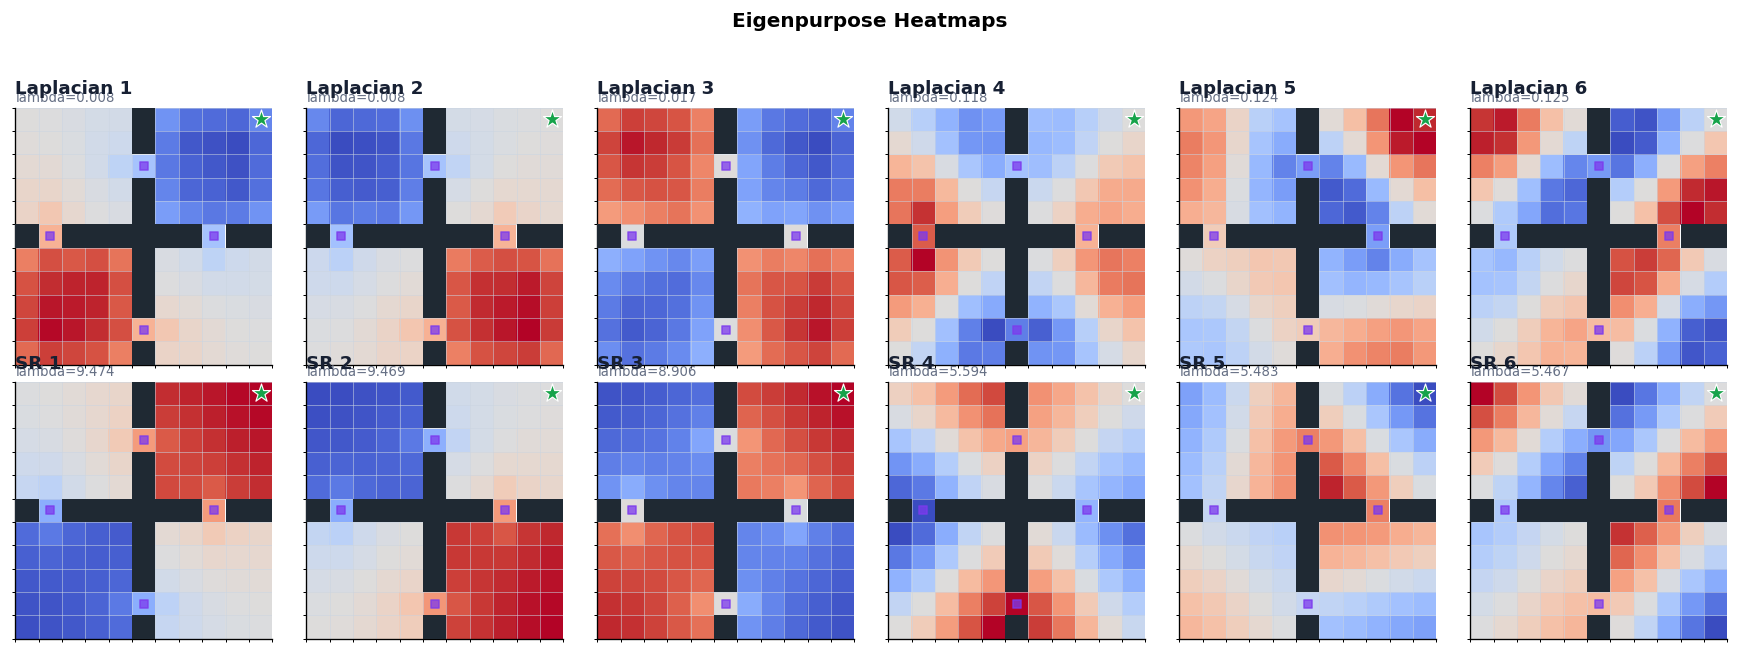

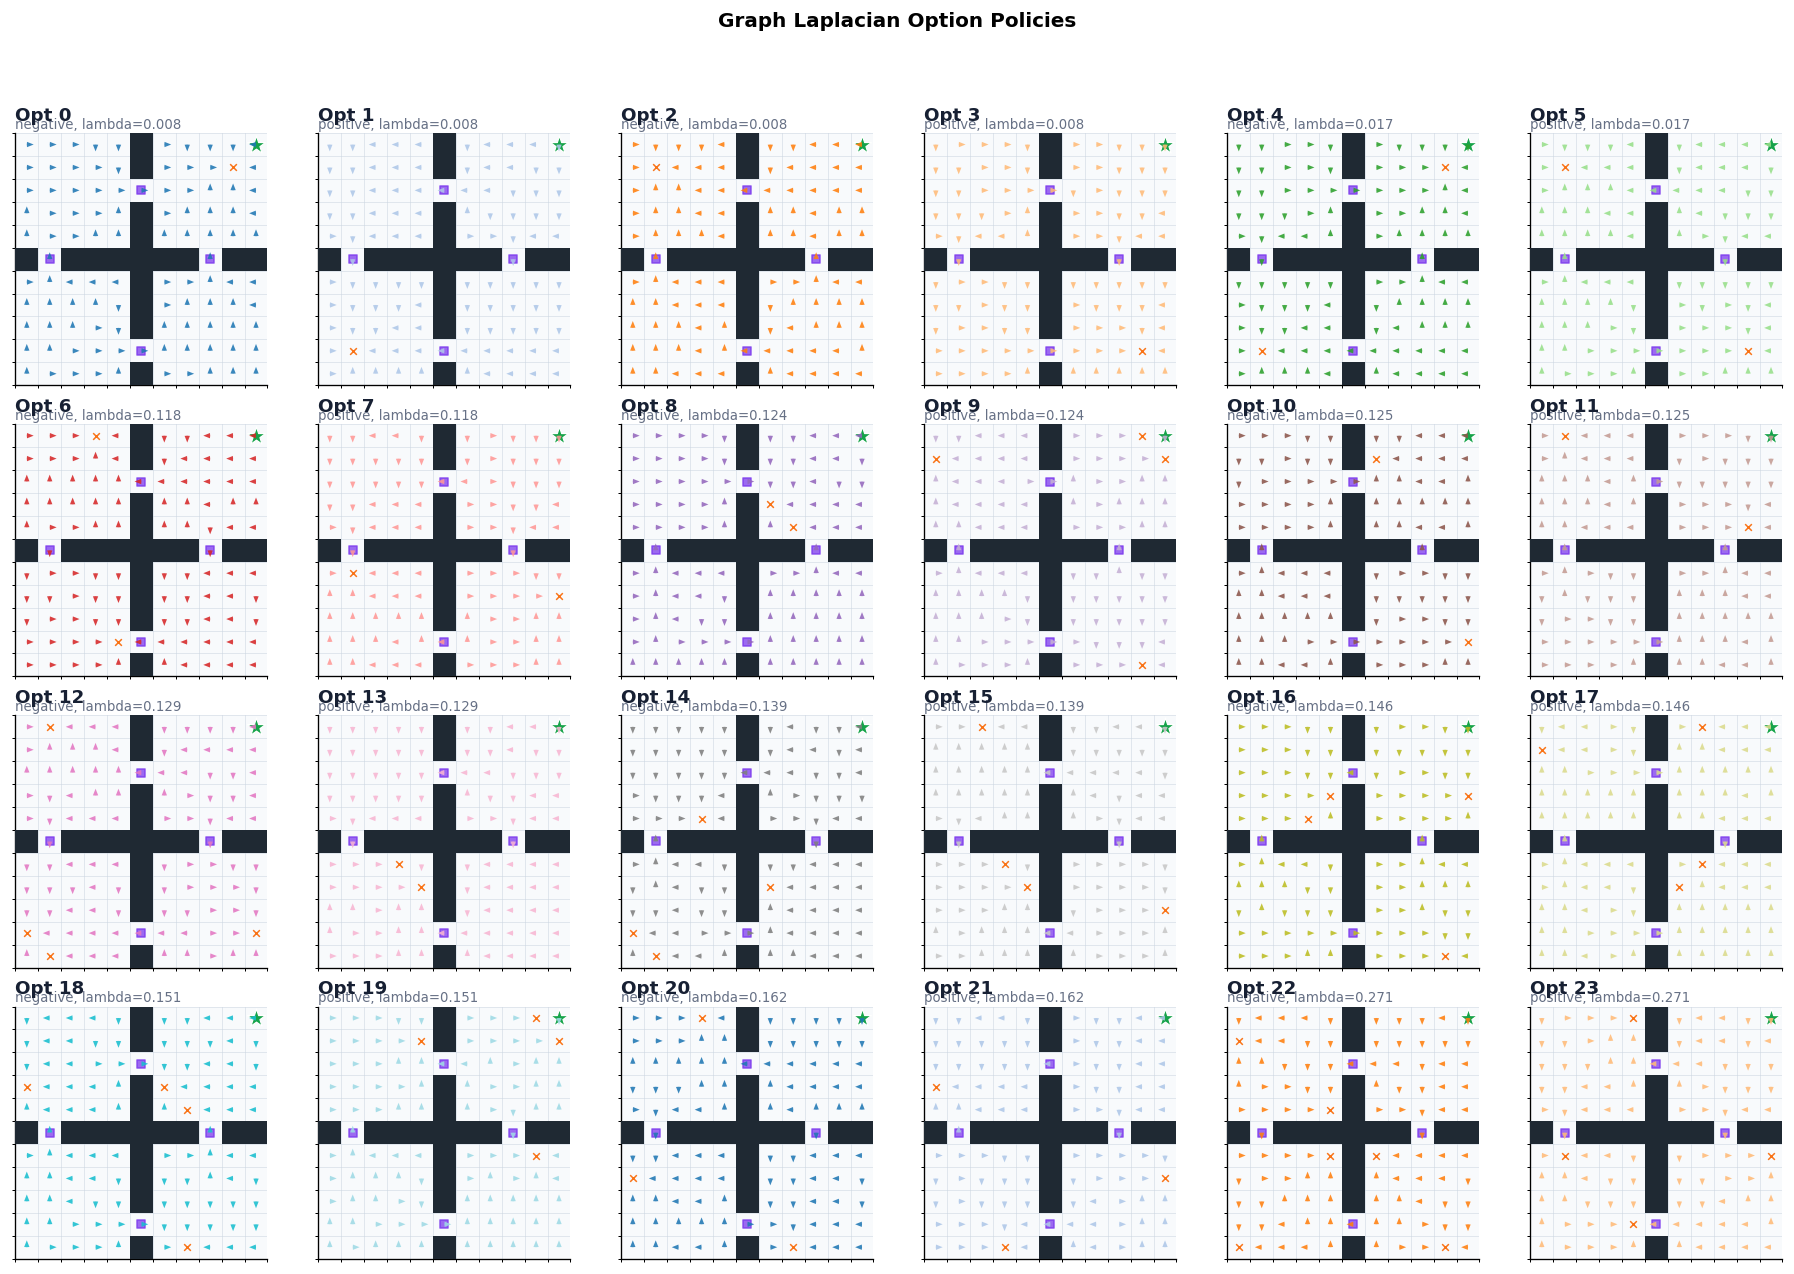

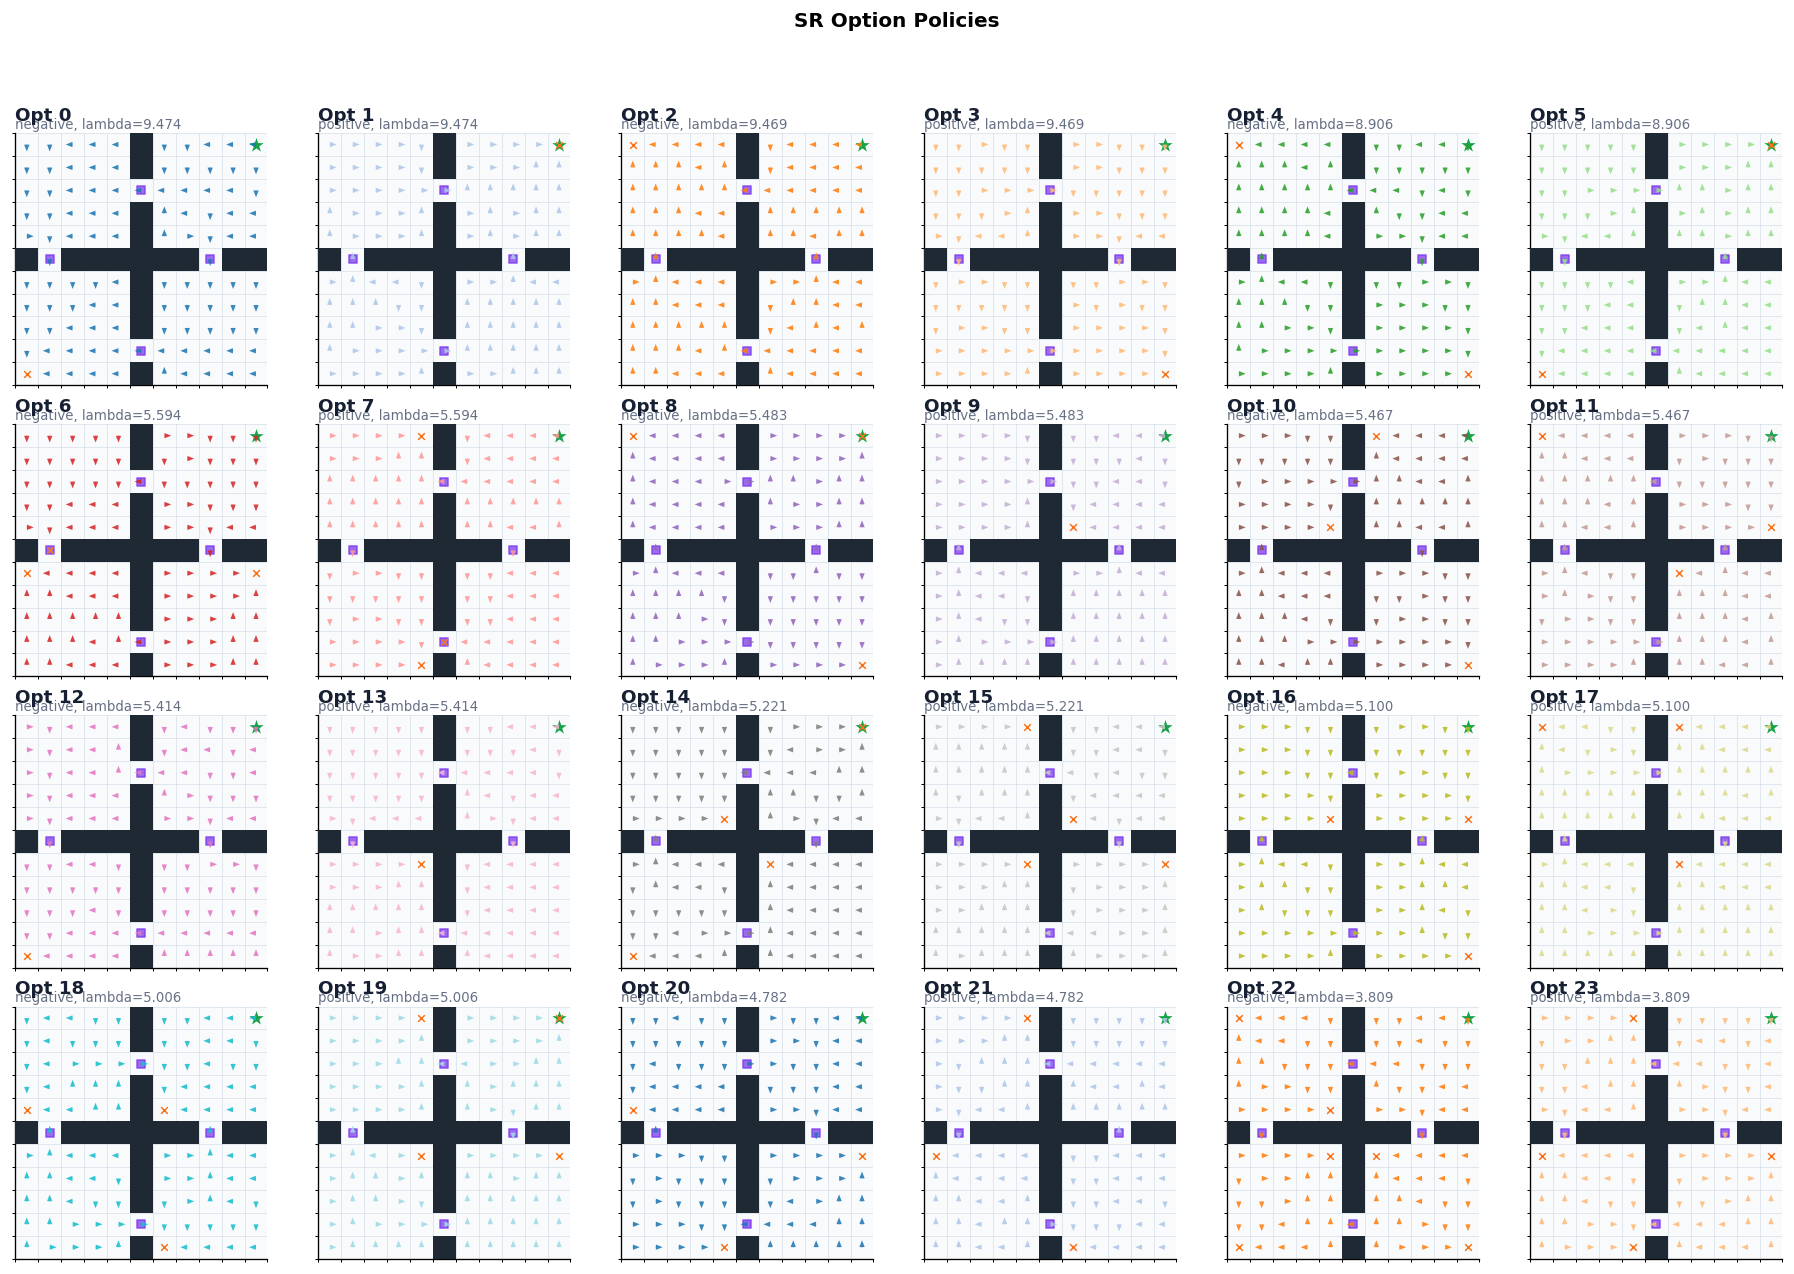

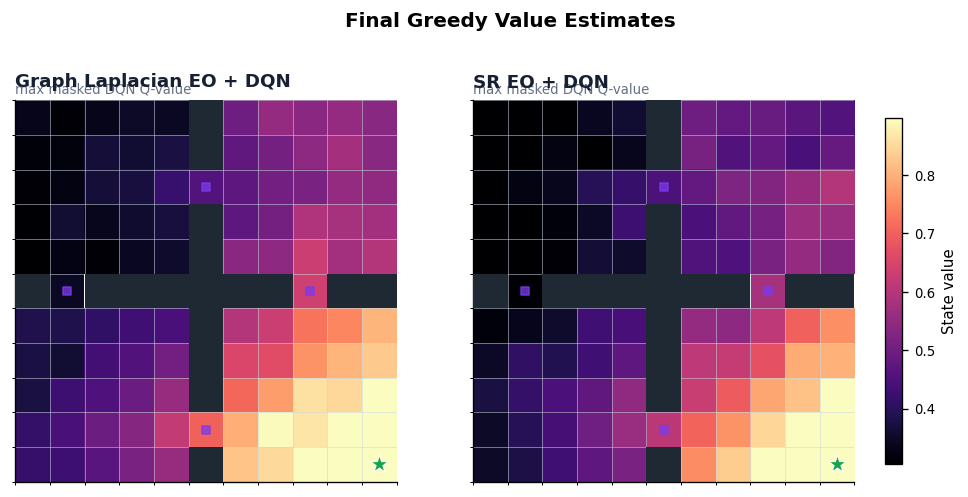

In [9]:
def plot_training_curves(results, hyperparams):
    metrics = [
        ("rewards", "Episode Return", "Higher is better"),
        ("success", "Success Rate", "Rolling goal reaches"),
        ("steps", "Primitive Steps", "Lower is better"),
        ("losses", "DQN Loss", "Huber loss on replay batches"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=False)
    axes = axes.ravel()
    window = hyperparams["plot_smooth_window"]

    for ax, (metric, title, subtitle) in zip(axes, metrics):
        for key in METHODS:
            x, mid, lo, hi = run_band(results[key][metric], window)
            color = COLORS[key]
            fill = COLORS[f"{key}_fill"]
            ax.plot(x, mid, color=color, linewidth=2.0, label=METHODS[key])
            ax.fill_between(x, lo, hi, color=fill, alpha=0.25, linewidth=0)
        for switch_ep in results["switch_episodes"]:
            if switch_ep is not None:
                ax.axvline(switch_ep, color=COLORS["switch"], linestyle="--", linewidth=1.1, alpha=0.85)
        ax.set_xlabel("Episode")
        ax.set_ylabel(title)
        ax.grid(alpha=0.25)
        set_panel_title(ax, title, f"{subtitle}; smooth window={window}; band=IQR")

    axes[0].legend(frameon=False, loc="lower right")
    fig.suptitle("Graph Laplacian vs SR Eigenoptions with DQN High-Level Control", fontweight="bold", y=0.99)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    maybe_save(fig, "01_training_curves.png")
    plt.show()


def plot_eigenvalue_spectra(spectral_data):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    lap_vals = spectral_data["laplacian_eigenvalues"][:50]
    sr_vals = spectral_data["sr_eigenvalues"][:50]
    axes[0].plot(np.arange(1, len(lap_vals) + 1), lap_vals, marker="o", markersize=3, color=COLORS["laplacian"])
    axes[1].plot(np.arange(len(sr_vals)), sr_vals, marker="o", markersize=3, color=COLORS["sr"])
    set_panel_title(axes[0], "Laplacian Spectrum", "Small eigenvalues are smooth graph modes")
    set_panel_title(axes[1], "SR Spectrum", "Large eigenvalues are slow predictive modes")
    for ax in axes:
        ax.set_xlabel("Eigenvector rank")
        ax.set_ylabel("Eigenvalue")
        ax.grid(alpha=0.25)
    fig.tight_layout()
    maybe_save(fig, "02_eigenvalue_spectra.png")
    plt.show()


def plot_eigenpurpose_heatmaps(spectral_data, env, num_vectors=6):
    fig, axes = plt.subplots(2, num_vectors, figsize=(2.45 * num_vectors, 5.4), constrained_layout=False)
    for col in range(num_vectors):
        lap_vec = spectral_data["laplacian_eigenvectors"][col]
        sr_vec = spectral_data["sr_eigenvectors"][col + 1]
        im0 = plot_state_heatmap(
            axes[0, col], env, lap_vec,
            f"Laplacian {col + 1}", f"lambda={spectral_data['laplacian_eigenvalues'][col]:.3f}",
            cmap="coolwarm", center_zero=True, goal=HYPERPARAMS["initial_goal"],
        )
        im1 = plot_state_heatmap(
            axes[1, col], env, sr_vec,
            f"SR {col + 1}", f"lambda={spectral_data['sr_eigenvalues'][col + 1]:.3f}",
            cmap="coolwarm", center_zero=True, goal=HYPERPARAMS["initial_goal"],
        )
    fig.suptitle("Eigenpurpose Heatmaps", fontweight="bold", y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    maybe_save(fig, "03_eigenpurpose_heatmaps.png")
    plt.show()


def plot_option_megaplot(options, env, title, max_options=24):
    shown = options[:max_options]
    cols = min(6, len(shown))
    rows = math.ceil(len(shown) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.55, rows * 2.65), constrained_layout=False)
    axes = np.asarray(axes).reshape(-1)
    for idx, option in enumerate(shown):
        ax = axes[idx]
        draw_env_grid(ax, env, goal=HYPERPARAMS["initial_goal"])
        draw_option_policy(ax, env, option, OPTION_CMAP[idx % len(OPTION_CMAP)])
        set_panel_title(ax, f"Opt {idx}", f"{option.direction}, lambda={option.eigenvalue:.3f}")
    for ax in axes[len(shown):]:
        ax.axis("off")
    fig.suptitle(title, fontweight="bold", y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    maybe_save(fig, f"04_{title.lower().replace(' ', '_')}.png")
    plt.show()


def plot_value_heatmaps(results, evaluation, hyperparams):
    env = FourRoomsEnv(goal_state=evaluation["goal"])
    values = {key: results[key]["final_agent"].state_values() for key in METHODS}
    finite = np.concatenate([v[np.isfinite(v)] for v in values.values()])
    vmin, vmax = np.percentile(finite, [5, 95]) if finite.size else (0.0, 1.0)
    if np.isclose(vmin, vmax):
        vmin -= 0.5
        vmax += 0.5

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
    ims = []
    for ax, key in zip(axes, METHODS):
        ims.append(plot_state_heatmap(ax, env, values[key], METHODS[key], "max masked DQN Q-value", cmap="magma", vmin=vmin, vmax=vmax, goal=evaluation["goal"]))
    cbar = fig.colorbar(ims[0], ax=axes, shrink=0.78, pad=0.03)
    cbar.set_label("State value")
    fig.suptitle("Final Greedy Value Estimates", fontweight="bold", y=0.98)
    maybe_save(fig, "05_value_heatmaps.png")
    plt.show()


plot_training_curves(experiment_results, HYPERPARAMS)
plot_eigenvalue_spectra(spectral_data)
plot_eigenpurpose_heatmaps(spectral_data, env_probe, HYPERPARAMS["plot_eigenvectors"])
plot_option_megaplot(option_sets["laplacian"], env_probe, "Graph Laplacian Option Policies", HYPERPARAMS["plot_options"])
plot_option_megaplot(option_sets["sr"], env_probe, "SR Option Policies", HYPERPARAMS["plot_options"])
plot_value_heatmaps(experiment_results, evaluation_results, HYPERPARAMS)


# Trajectory Plots
Greedy rollouts show how the trained DQN controller composes primitive actions and options.


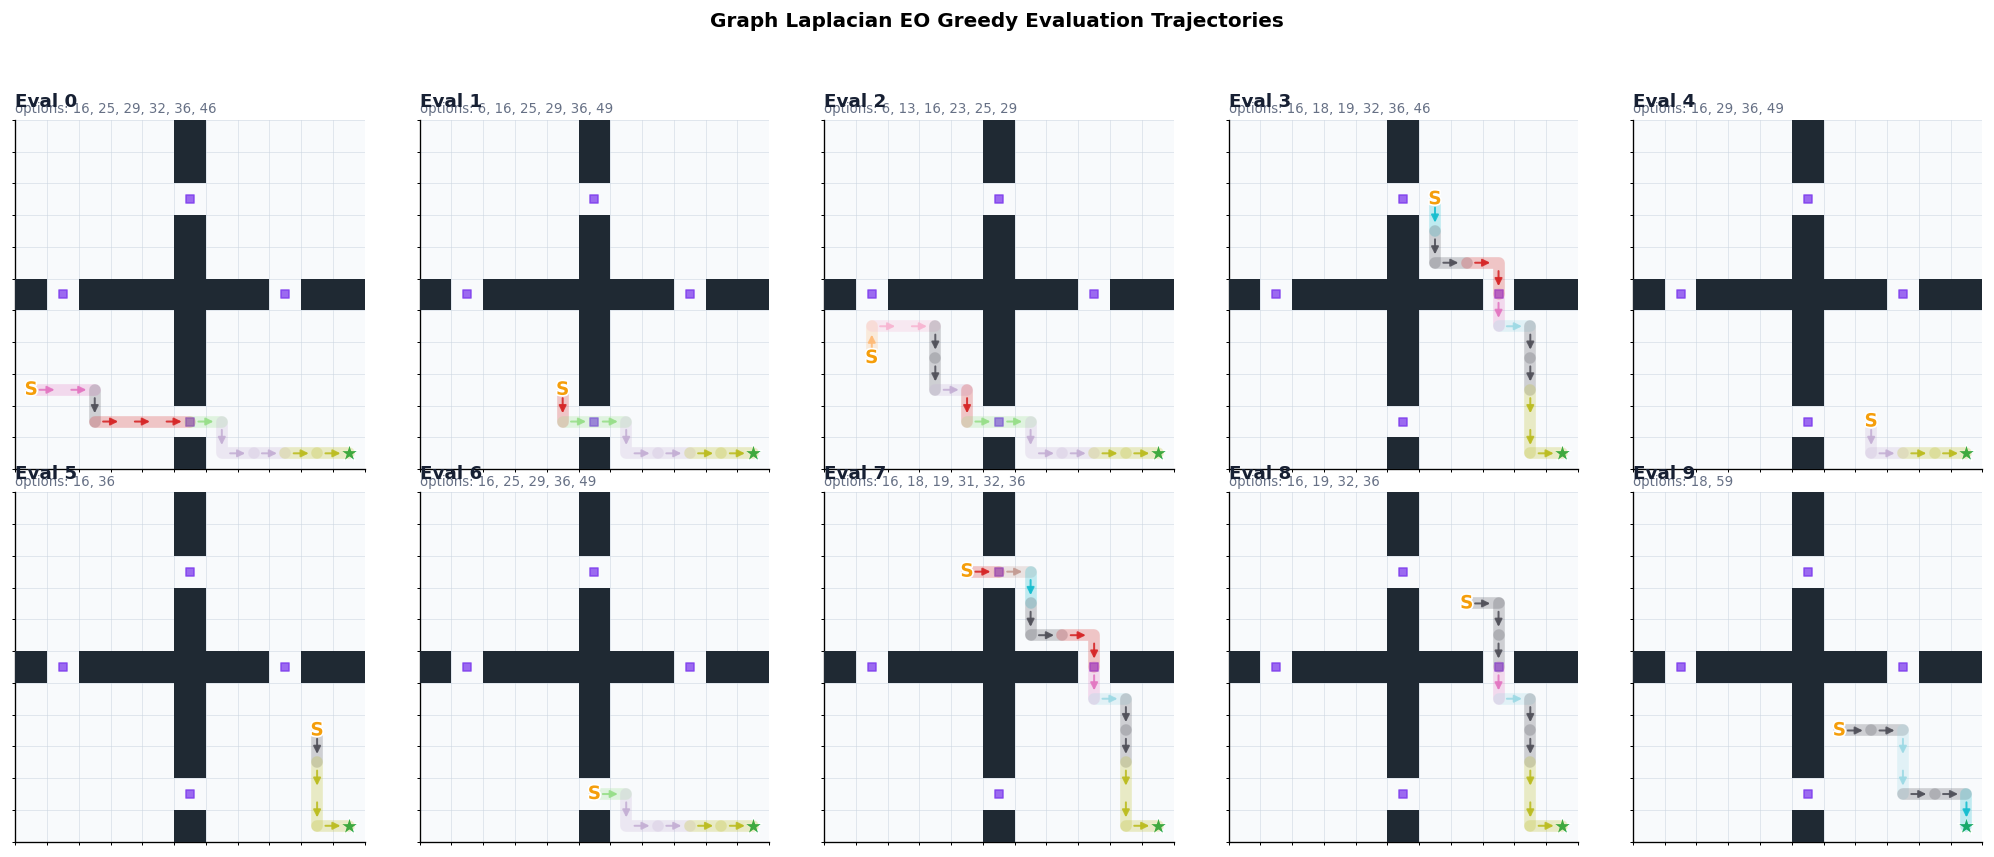

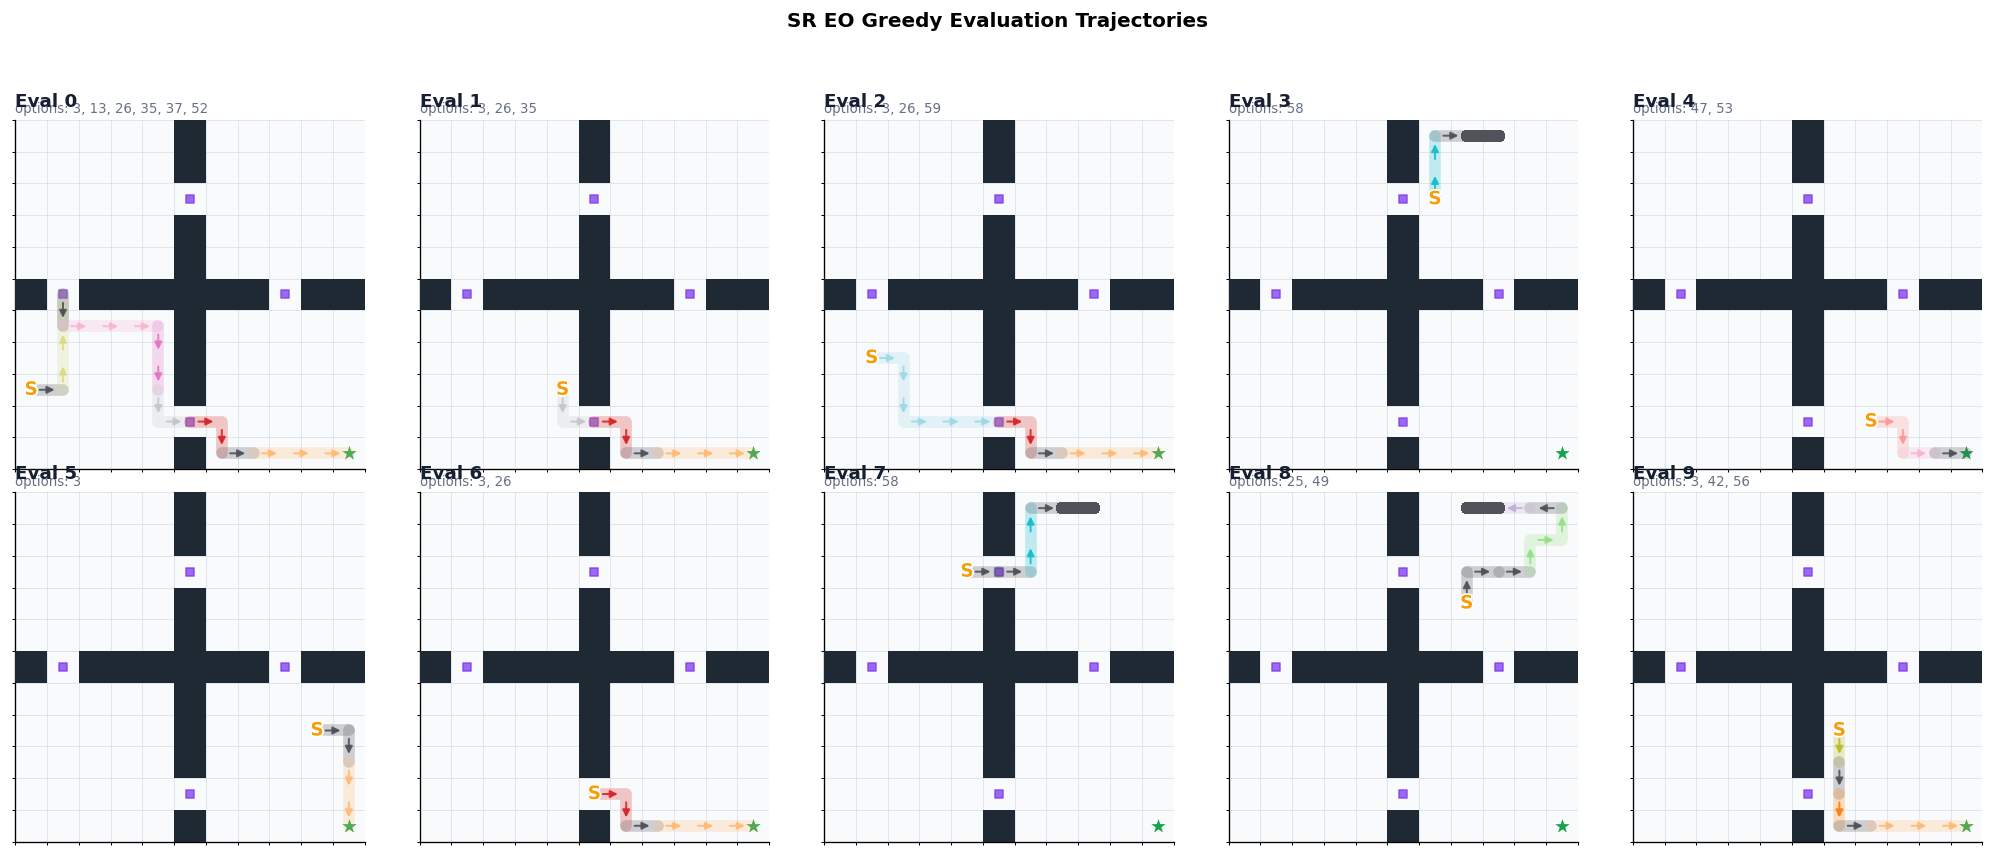

In [10]:
def plot_episode_trajectories(trajectories, env, title_prefix, max_episodes=10):
    episode_ids = sorted(trajectories.keys())[:max_episodes]
    cols = min(5, len(episode_ids))
    rows = math.ceil(len(episode_ids) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.4, rows * 3.55), constrained_layout=False)
    axes = np.asarray(axes).reshape(-1)

    for plot_idx, ep in enumerate(episode_ids):
        ax = axes[plot_idx]
        traj = trajectories[ep]
        draw_env_grid(ax, env, goal=env.goal_state)
        if traj and traj[0]["transitions"]:
            start = traj[0]["transitions"][0][0]
            ax.text(
                start[1], start[0], "S",
                color=COLORS["start"], weight="bold", fontsize=11,
                ha="center", va="center", zorder=9,
                path_effects=[path_effects.withStroke(linewidth=2, foreground="white")],
            )
        used = sorted({step["high_level_action"] - 4 for step in traj if step["high_level_action"] >= 4})
        subtitle = "options: " + ", ".join(map(str, used[:6])) if used else "primitive only"
        set_panel_title(ax, f"Eval {ep}", subtitle)

        for step in traj:
            color = high_level_action_color(step["high_level_action"])
            if not step["transitions"]:
                continue
            xs = [step["transitions"][0][0][1]]
            ys = [step["transitions"][0][0][0]]
            for state, next_state in step["transitions"]:
                xs.append(next_state[1])
                ys.append(next_state[0])
            ax.plot(xs, ys, color=color, linewidth=7, alpha=0.25, solid_capstyle="round", zorder=6)
            for state, next_state in step["transitions"]:
                x1, y1 = state[1], state[0]
                x2, y2 = next_state[1], next_state[0]
                if x1 == x2 and y1 == y2:
                    continue
                ax.add_patch(mpatches.FancyArrowPatch(
                    (x1, y1), (x2, y2),
                    arrowstyle="-|>", mutation_scale=9, linewidth=1.2,
                    color=color, alpha=0.9, shrinkA=5, shrinkB=5, zorder=7,
                ))

    for ax in axes[len(episode_ids):]:
        ax.axis("off")
    fig.suptitle(f"{title_prefix} Greedy Evaluation Trajectories", fontweight="bold", y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    maybe_save(fig, f"06_{title_prefix.lower().replace(' ', '_')}_trajectories.png")
    plt.show()


eval_env = FourRoomsEnv(goal_state=evaluation_results["goal"])
plot_episode_trajectories(evaluation_results["laplacian"]["trajectories"], eval_env, "Graph Laplacian EO")
plot_episode_trajectories(evaluation_results["sr"]["trajectories"], eval_env, "SR EO")


# Explainability Diagnostics
These plots focus on what the options explain: where they can start, where they stop, whether they align with bottlenecks, how the controller uses them, and how similar the two option sets are.


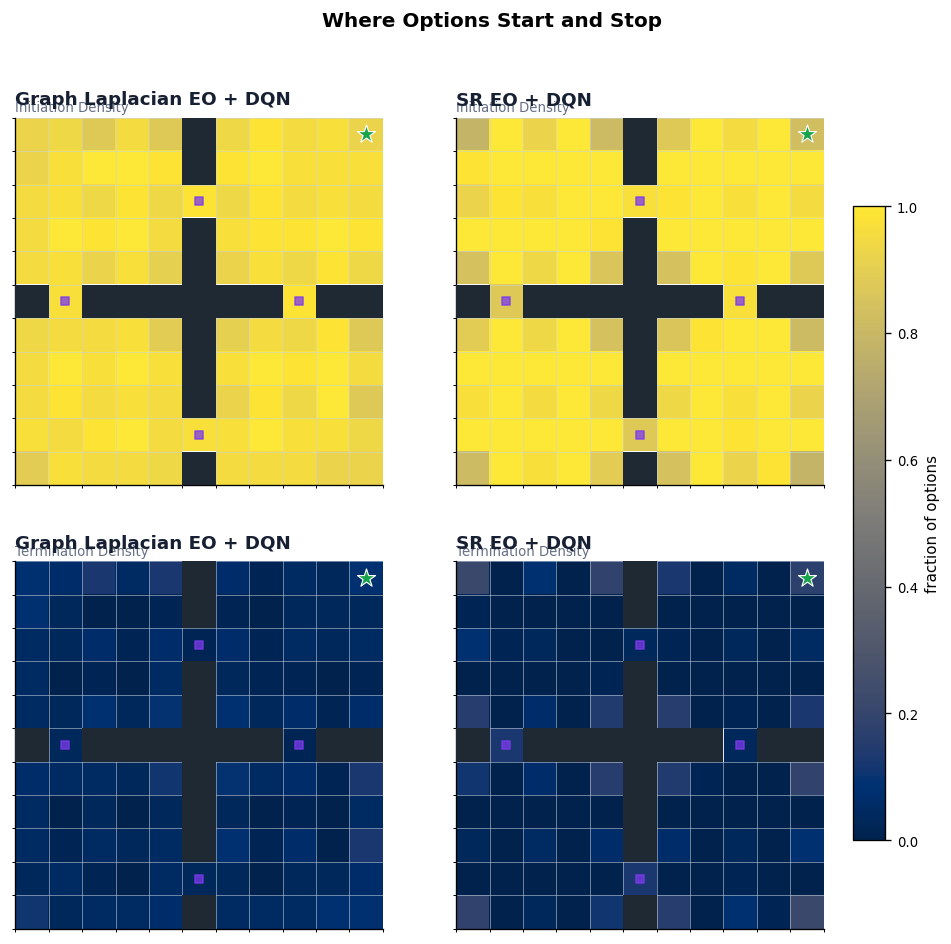

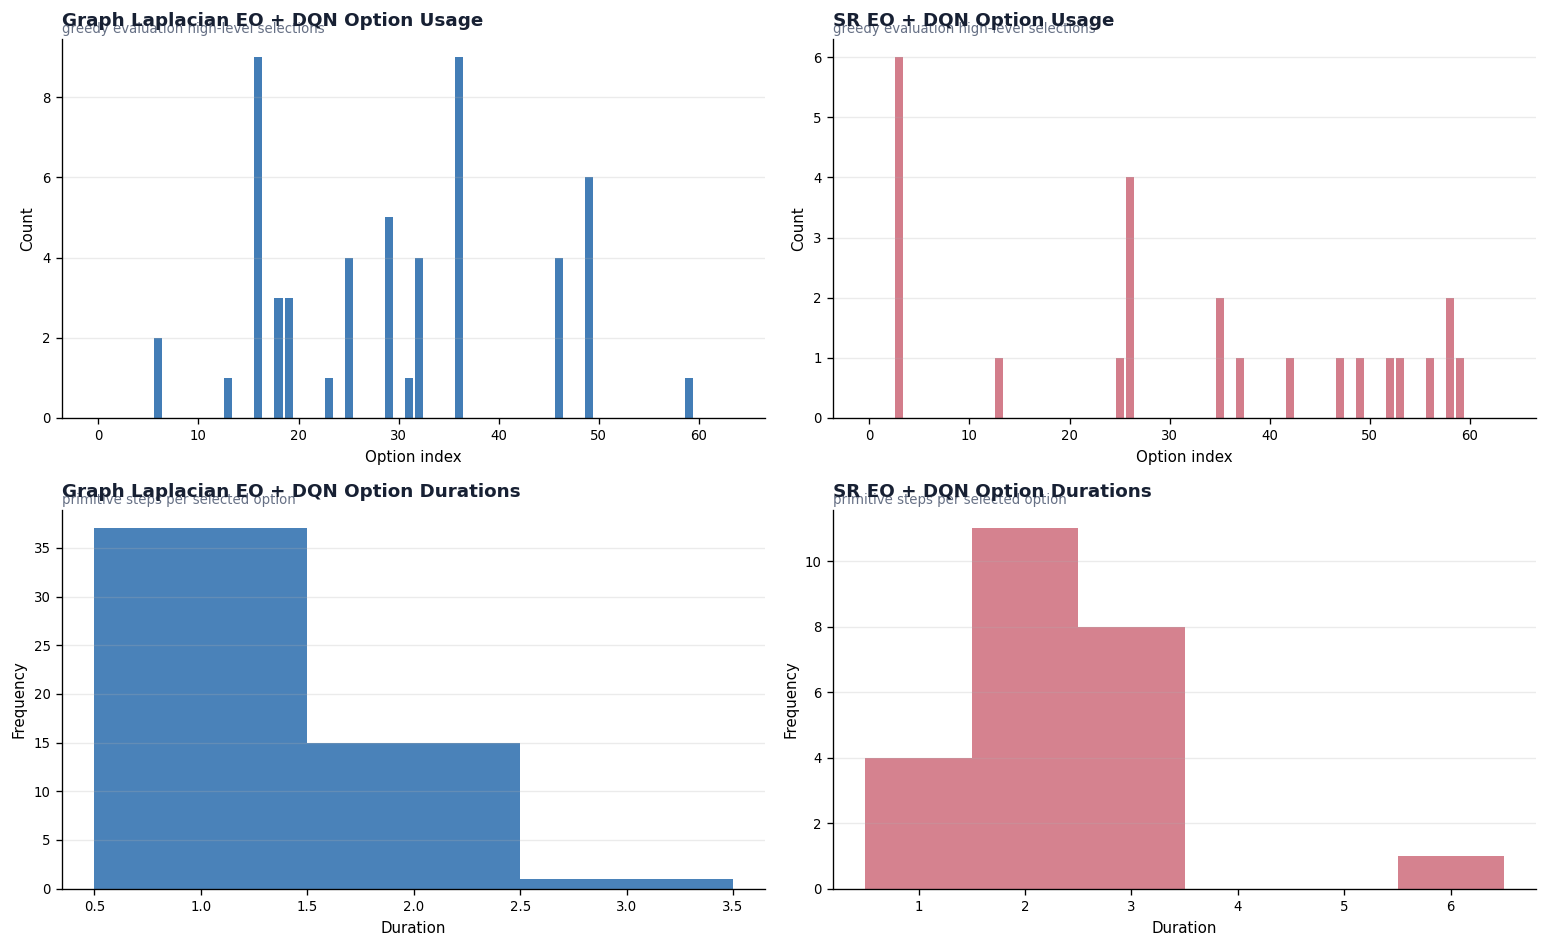

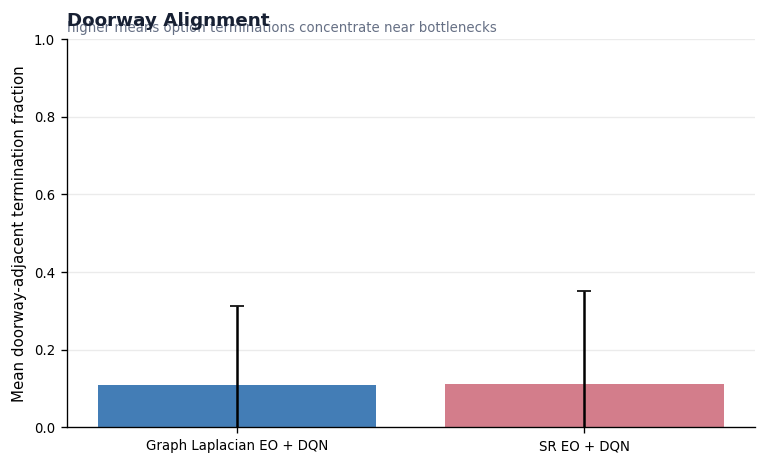

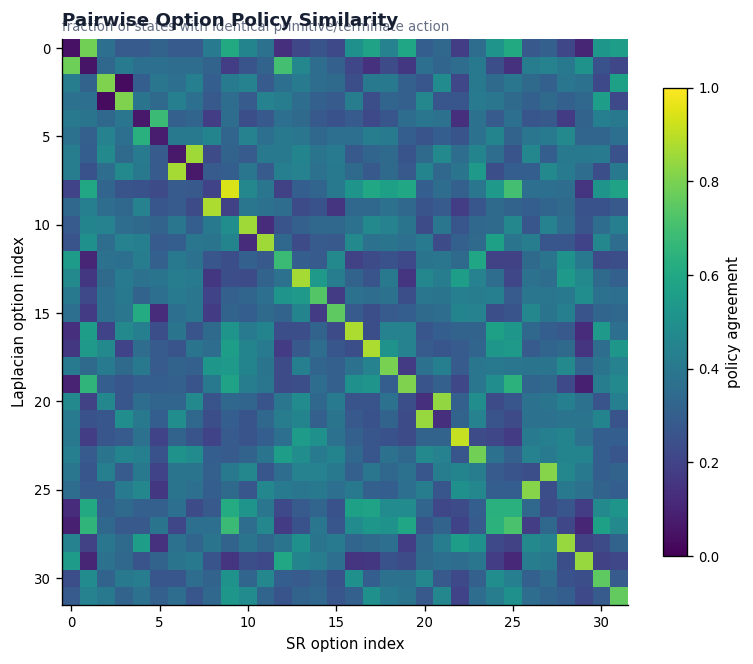

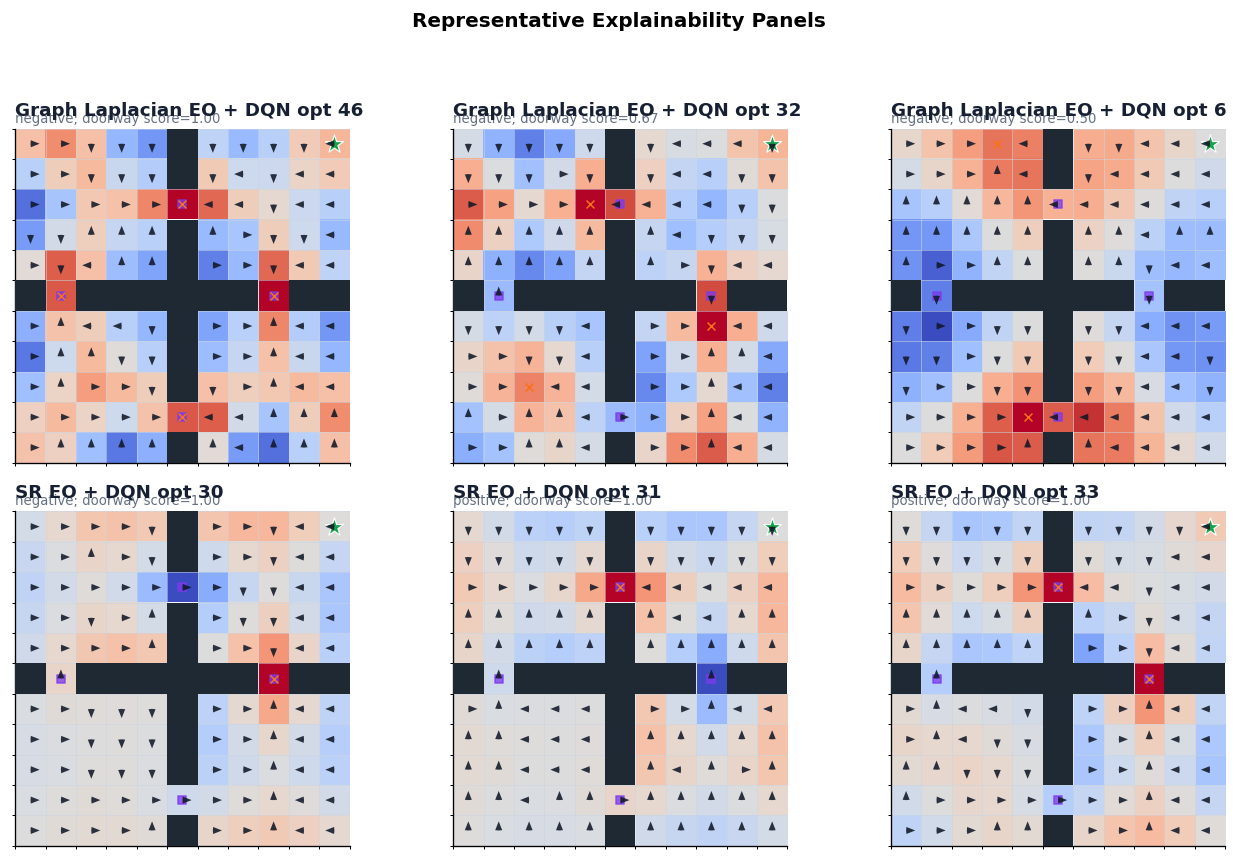

In [11]:
def option_density(options, env, attr):
    values = np.zeros(env.num_states, dtype=np.float64)
    for option in options:
        states = getattr(option, attr)
        values[states] += 1.0
    return values / max(1, len(options))


def doorway_alignment(options, env, radius=1):
    doorway_set = env.doorway_list
    scores = []
    for option in options:
        terms = option.termination_states
        if len(terms) == 0:
            scores.append(0.0)
            continue
        hits = 0
        for s_idx in terms:
            r, c = env.idx_to_state[int(s_idx)]
            if any(abs(r - dr) + abs(c - dc) <= radius for dr, dc in doorway_set):
                hits += 1
        scores.append(hits / len(terms))
    return np.asarray(scores, dtype=np.float64)


def option_policy_similarity(left_options, right_options, max_options=32):
    left = left_options[:max_options]
    right = right_options[:max_options]
    sim = np.zeros((len(left), len(right)), dtype=np.float64)
    for i, left_option in enumerate(left):
        for j, right_option in enumerate(right):
            sim[i, j] = np.mean(left_option.pi == right_option.pi)
    return sim


def plot_density_maps(option_sets, env):
    fig, axes = plt.subplots(2, 2, figsize=(10.6, 8.8), constrained_layout=False)
    for row, attr in enumerate(["initiation_states", "termination_states"]):
        for col, key in enumerate(METHODS):
            density = option_density(option_sets[key], env, attr)
            title = "Initiation Density" if attr == "initiation_states" else "Termination Density"
            im = plot_state_heatmap(
                axes[row, col], env, density,
                f"{METHODS[key]}", title,
                cmap="cividis", vmin=0.0, vmax=1.0, goal=HYPERPARAMS["initial_goal"],
            )
    fig.colorbar(im, ax=axes, shrink=0.78, pad=0.03, label="fraction of options")
    fig.suptitle("Where Options Start and Stop", fontweight="bold", y=0.98)
    maybe_save(fig, "07_initiation_termination_density.png")
    plt.show()


def plot_usage_duration_alignment(option_sets, evaluation, env):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=False)

    for col, key in enumerate(METHODS):
        usage = evaluation[key]["option_usage"]
        counts = np.array([usage.get(i, 0) for i in range(len(option_sets[key]))], dtype=np.float64)
        axes[0, col].bar(np.arange(len(counts)), counts, color=COLORS[key], alpha=0.85)
        set_panel_title(axes[0, col], f"{METHODS[key]} Option Usage", "greedy evaluation high-level selections")
        axes[0, col].set_xlabel("Option index")
        axes[0, col].set_ylabel("Count")
        axes[0, col].grid(axis="y", alpha=0.25)

        durations = evaluation[key]["option_durations"]
        if durations:
            axes[1, col].hist(durations, bins=np.arange(1, max(durations) + 2) - 0.5, color=COLORS[key], alpha=0.82)
        set_panel_title(axes[1, col], f"{METHODS[key]} Option Durations", "primitive steps per selected option")
        axes[1, col].set_xlabel("Duration")
        axes[1, col].set_ylabel("Frequency")
        axes[1, col].grid(axis="y", alpha=0.25)

    fig.tight_layout()
    maybe_save(fig, "08_usage_duration.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(7.4, 4.2))
    labels, means, errors = [], [], []
    for key in METHODS:
        scores = doorway_alignment(option_sets[key], env)
        labels.append(METHODS[key])
        means.append(float(np.mean(scores)))
        errors.append(float(np.std(scores)))
    ax.bar(labels, means, yerr=errors, color=[COLORS["laplacian"], COLORS["sr"]], alpha=0.85, capsize=4)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Mean doorway-adjacent termination fraction")
    ax.grid(axis="y", alpha=0.25)
    set_panel_title(ax, "Doorway Alignment", "higher means option terminations concentrate near bottlenecks")
    maybe_save(fig, "09_doorway_alignment.png")
    plt.show()


def plot_policy_similarity(option_sets):
    max_options = min(32, len(option_sets["laplacian"]), len(option_sets["sr"]))
    sim = option_policy_similarity(option_sets["laplacian"], option_sets["sr"], max_options=max_options)
    fig, ax = plt.subplots(figsize=(7.6, 6.5))
    im = ax.imshow(sim, cmap="viridis", vmin=0.0, vmax=1.0)
    ax.set_xlabel("SR option index")
    ax.set_ylabel("Laplacian option index")
    set_panel_title(ax, "Pairwise Option Policy Similarity", "fraction of states with identical primitive/terminate action")
    fig.colorbar(im, ax=ax, shrink=0.78, label="policy agreement")
    maybe_save(fig, "10_policy_similarity.png")
    plt.show()


def representative_options(options, env, count=3):
    scores = doorway_alignment(options, env)
    if len(scores) == 0:
        return []
    ranked = np.argsort(-scores)
    chosen = []
    for idx in ranked:
        if idx not in chosen:
            chosen.append(int(idx))
        if len(chosen) == count:
            break
    return chosen


def plot_representative_explainability(option_sets, env):
    count = 3
    fig, axes = plt.subplots(2, count, figsize=(count * 3.7, 7.2), constrained_layout=False)
    for row, key in enumerate(METHODS):
        indices = representative_options(option_sets[key], env, count=count)
        for col, opt_idx in enumerate(indices):
            option = option_sets[key][opt_idx]
            ax = axes[row, col]
            plot_state_heatmap(
                ax,
                env,
                option.eigenpurpose,
                f"{METHODS[key]} opt {opt_idx}",
                f"{option.direction}; doorway score={doorway_alignment([option], env)[0]:.2f}",
                cmap="coolwarm",
                center_zero=True,
                goal=HYPERPARAMS["initial_goal"],
            )
            draw_option_policy(ax, env, option, color="#111827", density=1.4)
    fig.suptitle("Representative Explainability Panels", fontweight="bold", y=0.99)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    maybe_save(fig, "11_representative_explainability.png")
    plt.show()


plot_density_maps(option_sets, env_probe)
plot_usage_duration_alignment(option_sets, evaluation_results, eval_env)
plot_policy_similarity(option_sets)
plot_representative_explainability(option_sets, env_probe)


# Summary Table
A compact numerical summary of the trained controllers and the option libraries.


In [12]:
def summarize_results(results, evaluation, option_sets, env):
    rows = []
    for key in METHODS:
        rewards = np.asarray(results[key]["rewards"], dtype=np.float64)
        success = np.asarray(results[key]["success"], dtype=np.float64)
        steps = np.asarray(results[key]["steps"], dtype=np.float64)
        scores = doorway_alignment(option_sets[key], env)
        rows.append({
            "method": METHODS[key],
            "final_train_return_mean": float(np.mean(rewards[:, -50:])),
            "final_train_success_mean": float(np.mean(success[:, -50:])),
            "final_train_steps_mean": float(np.mean(steps[:, -50:])),
            "eval_success_mean": float(np.mean(evaluation[key]["success"])),
            "eval_steps_mean": float(np.mean(evaluation[key]["steps"])),
            "mean_doorway_alignment": float(np.mean(scores)),
            "options_used_in_eval": int(len(evaluation[key]["option_usage"])),
        })
    return rows


summary_rows = summarize_results(experiment_results, evaluation_results, option_sets, env_probe)
for row in summary_rows:
    print("\n" + row["method"])
    for key, value in row.items():
        if key == "method":
            continue
        if isinstance(value, float):
            print(f"  {key}: {value:.3f}")
        else:
            print(f"  {key}: {value}")

print("\nGoal switch episodes:", experiment_results["switch_episodes"])
print("Evaluation goal:", evaluation_results["goal"])



Graph Laplacian EO + DQN
  final_train_return_mean: 0.930
  final_train_success_mean: 0.930
  final_train_steps_mean: 46.190
  eval_success_mean: 1.000
  eval_steps_mean: 9.100
  mean_doorway_alignment: 0.109
  options_used_in_eval: 14

SR EO + DQN
  final_train_return_mean: 0.960
  final_train_success_mean: 0.960
  final_train_steps_mean: 50.230
  eval_success_mean: 0.700
  eval_steps_mean: 65.900
  mean_doorway_alignment: 0.110
  options_used_in_eval: 14

Goal switch episodes: [369, 386]
Evaluation goal: (10, 10)
